In [1]:
import xarray as xr
from pathlib import Path
import xarray as xr
import numpy as np
import cartopy.crs as ccrs 
import xesmf

import pandas as pd
import glob
import warnings
import os


warnings.filterwarnings("ignore", category=UserWarning) #mute warnings 


In [2]:
#1. set up target grid with details --AUS18 . This is the target grid used to reproject NARCliM2.0
# need to be changes if regridding 4km res SE Australia region 
target_grid_details={
    'lon':(
        112, # 136, min longitude (corner of corner point)
        155, # 158, max longitude (corner of corner point)
        216, # 441, number of grid points + 1
    ),
    'lat':(
        -45, # min latitude (corner of corner point)
        -9, # max latitude (corner of corner point)
        181, # number of grid points + 1
    )
}
def generate_grid(grid_dict):
    lons=np.linspace(*grid_dict['lon'])
    lats=np.linspace(*grid_dict['lat'])
    return lons,lats
    
def create_target_grid():
    tlon_b,tlat_b=generate_grid(target_grid_details)
    tlon=0.5*(tlon_b[:-1]+tlon_b[1:])
    tlat=0.5*(tlat_b[:-1]+tlat_b[1:])
    dummy=np.zeros((len(tlon),len(tlat)))
    target_grid=xr.DataArray(dummy,dims=['lon','lat']).to_dataset(name='target_grid')
    return target_grid.assign_coords({'lon':tlon,'lat':tlat,'lon_b':tlon_b,'lat_b':tlat_b}).transpose()


In [3]:

#2.
#2.1 tmax
#regrid AGCD to target grid which is consistent with NARCliM2.0 
#individual variable [superseded] 
import xarray as xr
import numpy as np
import xesmf as xe
import dask
from pathlib import Path

# ---------- Paths ----------
agcd_base_path = Path("/g/data/zv2/agcd/v1-0-4/tmax/mean/r005/01day/")
run_path = Path("/scratch/dt6/xw9650/tmp").resolve()
output_base = run_path / "regridded_AGCD"
output_base.mkdir(exist_ok=True)

# ---------- Target grid ----------
target_grid = create_target_grid()

# ---------- Files ----------
agcd_files = sorted(agcd_base_path.glob("agcd_v1_tmax_mean_r005_daily_*.nc"))
print(f"Found {len(agcd_files)} files.")
if not agcd_files:
    raise RuntimeError("No AGCD files found.")

# ---------- Build/reuse regrid weights ----------
weights_path = output_base / "agcd_to_target_conservative_weights.nc"

with xr.open_dataset(agcd_files[0], chunks={"time": 30}) as ds0:
    ds0 = ds0.assign_coords(lon=np.mod(ds0.lon, 360)).sortby("lon")

    regridder = xe.Regridder(
        ds0,
        target_grid,
        method="conservative",
        filename=str(weights_path),
        reuse_weights=weights_path.exists(),  # create first time, reuse later
    )

# ---------- Process each file ----------
for agcd_file in agcd_files:
    print(f"Processing {agcd_file} ...")

    with xr.open_dataset(agcd_file, chunks={"time": 30}) as ds:
        ds = ds.assign_coords(lon=np.mod(ds.lon, 360)).sortby("lon")

        regridded_ds = regridder(ds, keep_attrs=True).drop_vars(
            ["lat_b", "lon_b", "time_bnds", "crs"],
            errors="ignore",
        )

        output_file = output_base / agcd_file.name

        # Optional compression
        encoding = {
            var: {"zlib": True, "complevel": 4}
            for var in regridded_ds.data_vars
        }

        delayed = regridded_ds.to_netcdf(
            output_file,
            compute=False,
            encoding=encoding,
        )
        dask.compute(delayed)

    print(f"Saved regridded file to {output_file}")


Found 116 files.
Processing /g/data/zv2/agcd/v1-0-4/tmax/mean/r005/01day/agcd_v1_tmax_mean_r005_daily_1910.nc ...
Saved regridded file to /scratch/dt6/xw9650/tmp/regridded_AGCD/agcd_v1_tmax_mean_r005_daily_1910.nc
Processing /g/data/zv2/agcd/v1-0-4/tmax/mean/r005/01day/agcd_v1_tmax_mean_r005_daily_1911.nc ...
Saved regridded file to /scratch/dt6/xw9650/tmp/regridded_AGCD/agcd_v1_tmax_mean_r005_daily_1911.nc
Processing /g/data/zv2/agcd/v1-0-4/tmax/mean/r005/01day/agcd_v1_tmax_mean_r005_daily_1912.nc ...
Saved regridded file to /scratch/dt6/xw9650/tmp/regridded_AGCD/agcd_v1_tmax_mean_r005_daily_1912.nc
Processing /g/data/zv2/agcd/v1-0-4/tmax/mean/r005/01day/agcd_v1_tmax_mean_r005_daily_1913.nc ...
Saved regridded file to /scratch/dt6/xw9650/tmp/regridded_AGCD/agcd_v1_tmax_mean_r005_daily_1913.nc
Processing /g/data/zv2/agcd/v1-0-4/tmax/mean/r005/01day/agcd_v1_tmax_mean_r005_daily_1914.nc ...
Saved regridded file to /scratch/dt6/xw9650/tmp/regridded_AGCD/agcd_v1_tmax_mean_r005_daily_1914.n

In [3]:

#2.
#2.2 tmin
#regrid AGCD to target grid which is consistent with NARCliM2.0 
#individual variable [superseded] 
import xarray as xr
import numpy as np
import xesmf as xe
import dask
from pathlib import Path

# ---------- Paths ----------
agcd_base_path = Path("/g/data/zv2/agcd/v1-0-4/tmin/mean/r005/01day/")
run_path = Path("/scratch/dt6/xw9650/tmp").resolve()
output_base = run_path / "regridded_AGCD"
output_base.mkdir(exist_ok=True)

# ---------- Target grid ----------
target_grid = create_target_grid()

# ---------- Files ----------
agcd_files = sorted(agcd_base_path.glob("agcd_v1_tmin_mean_r005_daily_*.nc"))
print(f"Found {len(agcd_files)} files.")
if not agcd_files:
    raise RuntimeError("No AGCD files found.")

# ---------- Build/reuse regrid weights ----------
weights_path = output_base / "agcd_to_target_conservative_weights.nc"

with xr.open_dataset(agcd_files[0], chunks={"time": 30}) as ds0:
    ds0 = ds0.assign_coords(lon=np.mod(ds0.lon, 360)).sortby("lon")

    regridder = xe.Regridder(
        ds0,
        target_grid,
        method="conservative",
        filename=str(weights_path),
        reuse_weights=weights_path.exists(),  # create first time, reuse later
    )

# ---------- Process each file ----------
for agcd_file in agcd_files:
    print(f"Processing {agcd_file} ...")

    with xr.open_dataset(agcd_file, chunks={"time": 30}) as ds:
        ds = ds.assign_coords(lon=np.mod(ds.lon, 360)).sortby("lon")

        regridded_ds = regridder(ds, keep_attrs=True).drop_vars(
            ["lat_b", "lon_b", "time_bnds", "crs"],
            errors="ignore",
        )

        output_file = output_base / agcd_file.name

        # Optional compression
        encoding = {
            var: {"zlib": True, "complevel": 4}
            for var in regridded_ds.data_vars
        }

        delayed = regridded_ds.to_netcdf(
            output_file,
            compute=False,
            encoding=encoding,
        )
        dask.compute(delayed)

    print(f"Saved regridded file to {output_file}")


Found 116 files.
Processing /g/data/zv2/agcd/v1-0-4/tmin/mean/r005/01day/agcd_v1_tmin_mean_r005_daily_1910.nc ...
Saved regridded file to /scratch/dt6/xw9650/tmp/regridded_AGCD/agcd_v1_tmin_mean_r005_daily_1910.nc
Processing /g/data/zv2/agcd/v1-0-4/tmin/mean/r005/01day/agcd_v1_tmin_mean_r005_daily_1911.nc ...
Saved regridded file to /scratch/dt6/xw9650/tmp/regridded_AGCD/agcd_v1_tmin_mean_r005_daily_1911.nc
Processing /g/data/zv2/agcd/v1-0-4/tmin/mean/r005/01day/agcd_v1_tmin_mean_r005_daily_1912.nc ...
Saved regridded file to /scratch/dt6/xw9650/tmp/regridded_AGCD/agcd_v1_tmin_mean_r005_daily_1912.nc
Processing /g/data/zv2/agcd/v1-0-4/tmin/mean/r005/01day/agcd_v1_tmin_mean_r005_daily_1913.nc ...
Saved regridded file to /scratch/dt6/xw9650/tmp/regridded_AGCD/agcd_v1_tmin_mean_r005_daily_1913.nc
Processing /g/data/zv2/agcd/v1-0-4/tmin/mean/r005/01day/agcd_v1_tmin_mean_r005_daily_1914.nc ...
Saved regridded file to /scratch/dt6/xw9650/tmp/regridded_AGCD/agcd_v1_tmin_mean_r005_daily_1914.n

In [4]:

#2.
#2.3 pr
#regrid AGCD to target grid which is consistent with NARCliM2.0 
#individual variable [superseded] 
import xarray as xr
import numpy as np
import xesmf as xe
import dask
from pathlib import Path

# ---------- Paths ----------
agcd_base_path = Path("/g/data/zv2/agcd/v1-0-4/precip/total/r005/01day/")
run_path = Path("/scratch/dt6/xw9650/tmp").resolve()
output_base = run_path / "regridded_AGCD"
output_base.mkdir(exist_ok=True)

# ---------- Target grid ----------
target_grid = create_target_grid()

# ---------- Files ----------
agcd_files = sorted(agcd_base_path.glob("agcd_v1_precip_total_r005_daily_*.nc"))
print(f"Found {len(agcd_files)} files.")
if not agcd_files:
    raise RuntimeError("No AGCD files found.")

# ---------- Build/reuse regrid weights ----------
weights_path = output_base / "agcd_to_target_conservative_weights.nc"

with xr.open_dataset(agcd_files[0], chunks={"time": 30}) as ds0:
    ds0 = ds0.assign_coords(lon=np.mod(ds0.lon, 360)).sortby("lon")

    regridder = xe.Regridder(
        ds0,
        target_grid,
        method="conservative",
        filename=str(weights_path),
        reuse_weights=weights_path.exists(),  # create first time, reuse later
    )

# ---------- Process each file ----------
for agcd_file in agcd_files:
    print(f"Processing {agcd_file} ...")

    with xr.open_dataset(agcd_file, chunks={"time": 30}) as ds:
        ds = ds.assign_coords(lon=np.mod(ds.lon, 360)).sortby("lon")

        regridded_ds = regridder(ds, keep_attrs=True).drop_vars(
            ["lat_b", "lon_b", "time_bnds", "crs"],
            errors="ignore",
        )

        output_file = output_base / agcd_file.name

        # Optional compression
        encoding = {
            var: {"zlib": True, "complevel": 4}
            for var in regridded_ds.data_vars
        }

        delayed = regridded_ds.to_netcdf(
            output_file,
            compute=False,
            encoding=encoding,
        )
        dask.compute(delayed)

    print(f"Saved regridded file to {output_file}")


Found 126 files.
Processing /g/data/zv2/agcd/v1-0-4/precip/total/r005/01day/agcd_v1_precip_total_r005_daily_1900.nc ...
Saved regridded file to /scratch/dt6/xw9650/tmp/regridded_AGCD/agcd_v1_precip_total_r005_daily_1900.nc
Processing /g/data/zv2/agcd/v1-0-4/precip/total/r005/01day/agcd_v1_precip_total_r005_daily_1901.nc ...
Saved regridded file to /scratch/dt6/xw9650/tmp/regridded_AGCD/agcd_v1_precip_total_r005_daily_1901.nc
Processing /g/data/zv2/agcd/v1-0-4/precip/total/r005/01day/agcd_v1_precip_total_r005_daily_1902.nc ...
Saved regridded file to /scratch/dt6/xw9650/tmp/regridded_AGCD/agcd_v1_precip_total_r005_daily_1902.nc
Processing /g/data/zv2/agcd/v1-0-4/precip/total/r005/01day/agcd_v1_precip_total_r005_daily_1903.nc ...
Saved regridded file to /scratch/dt6/xw9650/tmp/regridded_AGCD/agcd_v1_precip_total_r005_daily_1903.nc
Processing /g/data/zv2/agcd/v1-0-4/precip/total/r005/01day/agcd_v1_precip_total_r005_daily_1904.nc ...
Saved regridded file to /scratch/dt6/xw9650/tmp/regridde

In [1]:
# (superseded) 3.generate annual statistics for AGCD 
# Separate data generation from plotting so you do not recompute every run.

import re
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt


def _year_tag(start_year=None, end_year=None):
    s = str(start_year) if start_year is not None else "start"
    e = str(end_year) if end_year is not None else "end"
    return f"{s}-{e}"


def _select_files(data_dir, variable, statistic="mean", member="r005", start_year=None, end_year=None):
    pattern = f"agcd_v1_{variable}_{statistic}_{member}_daily_*.nc"
    files_all = sorted(Path(data_dir).glob(pattern))
    if not files_all:
        raise FileNotFoundError(f"No files found for pattern: {pattern}")

    files = []
    for f in files_all:
        m = re.search(r"(\d{4})", f.name)
        if not m:
            continue
        y = int(m.group(1))
        if start_year is not None and y < start_year:
            continue
        if end_year is not None and y > end_year:
            continue
        files.append(f)

    if not files:
        raise FileNotFoundError("No files remain after year filtering.")
    return files


def generate_annual_and_spatial_stats(
    variable,
    data_dir=Path("/scratch/dt6/xw9650/tmp/regridded_AGCD"),
    mask_file=Path("/scratch/dt6/xw9650/tmp/regridded/sftlf_AUS-18_ACCESS-ESM1-5_historical_r6i1p1f1_NSW-Government_NARCliM2-0-WRF412R3_v1-r1_fx.nc"),
    statistic="mean",
    member="r005",
    start_year=None,
    end_year=None,
    overwrite=False,
):
    data_dir = Path(data_dir)
    tag = _year_tag(start_year, end_year)
    yearly_csv = data_dir / f"annual_mean_p99_land_{variable}_{tag}.csv"
    spatial_nc = data_dir / f"{variable}_spatial_mean_p99_alltime_land_{tag}.nc"

    if yearly_csv.exists() and spatial_nc.exists() and not overwrite:
        print(f"[{variable}] Using existing files (overwrite=False):")
        print(f"  {yearly_csv}")
        print(f"  {spatial_nc}")
        return yearly_csv, spatial_nc

    files = _select_files(
        data_dir=data_dir,
        variable=variable,
        statistic=statistic,
        member=member,
        start_year=start_year,
        end_year=end_year,
    )
    print(f"[{variable}] Computing stats from {len(files)} files...")

    # Load mask once
    land_mask_ds = xr.open_dataset(mask_file)
    land_mask = land_mask_ds["sftlf"] > 50
    if "lon" in land_mask.coords:
        land_mask = land_mask.assign_coords(lon=np.mod(land_mask.lon, 360)).sortby("lon")

    # ---- yearly timeseries stats ----
    years, annual_mean_vals, annual_p99_vals = [], [], []

    for f in files:
        print(f"[{variable}] Yearly stats: {f.name}")
        ds = xr.open_dataset(f, chunks={"time": -1})

        da = ds[variable] if variable in ds.data_vars else ds[list(ds.data_vars)[0]]
        if "lon" in da.coords:
            da = da.assign_coords(lon=np.mod(da.lon, 360)).sortby("lon")

        if "time" in da.coords and da.time.size > 0:
            year = int(da.time.dt.year.values[0])
        else:
            m = re.search(r"(\d{4})", f.name)
            year = int(m.group(1)) if m else np.nan

        da_aligned, lm_aligned = xr.align(da, land_mask, join="inner")
        da_land = da_aligned.where(lm_aligned)

        annual_mean_grid = da_land.mean(dim="time", skipna=True)
        annual_p99_grid = da_land.quantile(0.99, dim="time", skipna=True)

        spatial_dims = [d for d in ["lat", "latitude", "y", "lon", "longitude", "x"] if d in annual_mean_grid.dims]
        if spatial_dims:
            annual_mean_val = annual_mean_grid.mean(dim=spatial_dims, skipna=True).compute().item()
            annual_p99_val = annual_p99_grid.mean(dim=spatial_dims, skipna=True).compute().item()
        else:
            annual_mean_val = annual_mean_grid.compute().item()
            annual_p99_val = annual_p99_grid.compute().item()

        years.append(year)
        annual_mean_vals.append(annual_mean_val)
        annual_p99_vals.append(annual_p99_val)
        ds.close()

    df = pd.DataFrame({
        "year": years,
        "annual_mean_land": annual_mean_vals,
        "annual_p99_land": annual_p99_vals,
    }).sort_values("year").reset_index(drop=True)
    df.to_csv(yearly_csv, index=False)
    print(f"[{variable}] Saved yearly stats: {yearly_csv}")

    # ---- whole-period spatial maps ----
    ds_all = xr.open_mfdataset(files, combine="by_coords", chunks={"time": 365})
    da_all = ds_all[variable] if variable in ds_all.data_vars else ds_all[list(ds_all.data_vars)[0]]
    if "lon" in da_all.coords:
        da_all = da_all.assign_coords(lon=np.mod(da_all.lon, 360)).sortby("lon")

    da_all, lm_all = xr.align(da_all, land_mask, join="inner")
    da_all_land = da_all.where(lm_all)

    spatial_mean_alltime = da_all_land.mean(dim="time", skipna=True)
    spatial_p99_alltime = da_all_land.quantile(0.99, dim="time", skipna=True)

    spatial_out = xr.Dataset({
        f"{variable}_mean_alltime_land": spatial_mean_alltime,
        f"{variable}_p99_alltime_land": spatial_p99_alltime,
    })
    spatial_out.to_netcdf(spatial_nc)
    print(f"[{variable}] Saved spatial maps: {spatial_nc}")

    ds_all.close()
    land_mask_ds.close()
    return yearly_csv, spatial_nc


def plot_saved_stats(variable, yearly_csv, spatial_nc):
    # ---- plot timeseries from CSV ----
    df_plot = pd.read_csv(yearly_csv)
    plt.figure(figsize=(10, 5))
    plt.plot(df_plot["year"], df_plot["annual_mean_land"], marker="o", label="Annual mean (land)")
    plt.plot(df_plot["year"], df_plot["annual_p99_land"], marker="s", label="Annual 99th percentile (land)")
    plt.xlabel("Year")
    plt.ylabel(variable)
    plt.title(f"{variable}: Land-only Annual Mean and 99th Percentile")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---- plot spatial maps from saved NetCDF ----
    ds_sp = xr.open_dataset(spatial_nc)
    mean_name = f"{variable}_mean_alltime_land"
    p99_name = f"{variable}_p99_alltime_land"

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ds_sp[mean_name].plot(ax=axes[0], cmap="viridis")
    axes[0].set_title(f"{variable} mean (all-time, land)")
    ds_sp[p99_name].plot(ax=axes[1], cmap="magma")
    axes[1].set_title(f"{variable} p99 (all-time, land)")
    plt.tight_layout()
    plt.show()
    ds_sp.close()


# -----------------------------
# Example usage
# -----------------------------
# 1) Generate once (or set overwrite=True to rebuild)
# yearly_csv, spatial_nc = generate_annual_and_spatial_stats(
#     variable="tmax",
#     start_year=1951,
#     end_year=2014,
#     overwrite=False,
# )

# 2) Plot anytime without recomputing
# plot_saved_stats("tmax", yearly_csv, spatial_nc)


In [1]:
#(superseded)3.generate annual AGCD statistics  
#modified -average tmax and tmin to calcuate tas , stats by NRM 
# -----------------------------------------
# Generate annual and spatial statistics
# for tmax, tmin, or tas (derived)
# summarised by NRM regions
# -----------------------------------------

import re
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import regionmask
import matplotlib.pyplot as plt


# -----------------------------
# helper functions
# -----------------------------

def _year_tag(start_year=None, end_year=None):
    s = str(start_year) if start_year is not None else "start"
    e = str(end_year) if end_year is not None else "end"
    return f"{s}-{e}"


def _select_files(data_dir, variable, statistic="mean", member="r005", start_year=None, end_year=None):

    pattern = f"agcd_v1_{variable}_{statistic}_{member}_daily_*.nc"
    files_all = sorted(Path(data_dir).glob(pattern))

    files = []
    for f in files_all:

        m = re.search(r"(\d{4})", f.name)
        if not m:
            continue

        y = int(m.group(1))

        if start_year and y < start_year:
            continue

        if end_year and y > end_year:
            continue

        files.append(f)

    return files


# -----------------------------
# main function
# -----------------------------

def generate_annual_and_spatial_stats(
        variable,
        data_dir,
        nrm_shapefile,
        statistic="mean",
        member="r005",
        start_year=None,
        end_year=None,
):

    data_dir = Path(data_dir)
    tag = _year_tag(start_year, end_year)

    yearly_csv = data_dir / f"annual_stats_{variable}_NRM_{tag}.csv"

    # -------------------------
    # Load NRM regions
    # -------------------------

    nrm_gdf = gpd.read_file(nrm_shapefile)
    nrm_gdf = nrm_gdf[nrm_gdf.geometry.notnull()].to_crs("EPSG:4326")

    nrm_names = nrm_gdf["label"].tolist()

    nrm_regions = regionmask.Regions(
        name="NRM",
        numbers=list(range(len(nrm_gdf))),
        names=nrm_names,
        outlines=[geom for geom in nrm_gdf.geometry],
    )

    # -------------------------
    # Select files
    # -------------------------

    if variable == "tas":

        files_tmax = _select_files(data_dir, "tmax", statistic, member, start_year, end_year)
        files_tmin = _select_files(data_dir, "tmin", statistic, member, start_year, end_year)

        files = list(zip(files_tmax, files_tmin))

    else:

        files = _select_files(data_dir, variable, statistic, member, start_year, end_year)

    records = []

    # -------------------------
    # Process yearly files
    # -------------------------

    for f in files:

        if variable == "tas":

            fmax, fmin = f
            print("Processing:", Path(fmax).name)

            ds_max = xr.open_dataset(fmax)
            ds_min = xr.open_dataset(fmin)

            da = (ds_max["tmax"] + ds_min["tmin"]) / 2

        else:

            print("Processing:", f.name)

            ds = xr.open_dataset(f)

            da = ds[variable] if variable in ds.data_vars else ds[list(ds.data_vars)[0]]

        # fix longitude if needed
        if "lon" in da.coords:
            da = da.assign_coords(lon=np.mod(da.lon, 360)).sortby("lon")

        year = int(da.time.dt.year.values[0])

        # -------------------------
        # Apply NRM mask
        # -------------------------

        nrm_mask = nrm_regions.mask(da)

        grouped = da.groupby(nrm_mask)

        mean_region = grouped.mean(dim=("time", "lat", "lon"), skipna=True)

        p99_region = grouped.quantile(0.99, dim=("time", "lat", "lon"), skipna=True)

        for r in mean_region[nrm_mask.name].values:

            if np.isnan(r):
                continue

            records.append({

                "year": year,

                "NRM": nrm_names[int(r)],

                "annual_mean": float(mean_region.sel({nrm_mask.name: r}).values),

                "annual_p99": float(p99_region.sel({nrm_mask.name: r}).values),

            })

        if variable == "tas":

            ds_max.close()
            ds_min.close()

        else:

            ds.close()

    df = pd.DataFrame(records)

    df = df.sort_values(["year", "NRM"])

    df.to_csv(yearly_csv, index=False)

    print("Saved:", yearly_csv)

    return yearly_csv


# -----------------------------
# plotting helper
# -----------------------------


def plot_nrm_timeseries(csv_file, metric="annual_p99"):

    df = pd.read_csv(csv_file)

    plt.figure(figsize=(10,6))

    for region in df["NRM"].unique():

        subset = df[df["NRM"] == region].sort_values("year")

        x = subset["year"].values
        y = subset[metric].values

        # Plot original time series
        plt.plot(x, y, label=region)

        # Fit linear trend
        if len(x) > 1:  # avoid errors for short series
            coeffs = np.polyfit(x, y, 1)  # degree 1 = linear
            trend = np.polyval(coeffs, x)

            # Plot trend line (dashed)
            plt.plot(x, trend, linestyle='--', alpha=0.7)

            # Optional: print slope
            print(f"{region} trend (slope per year): {coeffs[0]:.4f}")

    plt.xlabel("Year")
    plt.ylabel(metric)
    plt.title(f"{metric} by NRM region with linear trends")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# -----------------------------
# Example usage
# -----------------------------

# csv_file = generate_annual_and_spatial_stats(
#     variable="tas",
#     data_dir="/scratch/dt6/xw9650/tmp/regridded_AGCD",
#     nrm_shapefile="NRM_regions.shp",
#     start_year=1951,
#     end_year=2014,
# )

# plot_nrm_timeseries(csv_file, "annual_mean")

Processing: agcd_v1_tmax_mean_r005_daily_1951.nc
Processing: agcd_v1_tmax_mean_r005_daily_1952.nc
Processing: agcd_v1_tmax_mean_r005_daily_1953.nc
Processing: agcd_v1_tmax_mean_r005_daily_1954.nc
Processing: agcd_v1_tmax_mean_r005_daily_1955.nc
Processing: agcd_v1_tmax_mean_r005_daily_1956.nc
Processing: agcd_v1_tmax_mean_r005_daily_1957.nc
Processing: agcd_v1_tmax_mean_r005_daily_1958.nc
Processing: agcd_v1_tmax_mean_r005_daily_1959.nc
Processing: agcd_v1_tmax_mean_r005_daily_1960.nc
Processing: agcd_v1_tmax_mean_r005_daily_1961.nc
Processing: agcd_v1_tmax_mean_r005_daily_1962.nc
Processing: agcd_v1_tmax_mean_r005_daily_1963.nc
Processing: agcd_v1_tmax_mean_r005_daily_1964.nc
Processing: agcd_v1_tmax_mean_r005_daily_1965.nc
Processing: agcd_v1_tmax_mean_r005_daily_1966.nc
Processing: agcd_v1_tmax_mean_r005_daily_1967.nc
Processing: agcd_v1_tmax_mean_r005_daily_1968.nc
Processing: agcd_v1_tmax_mean_r005_daily_1969.nc
Processing: agcd_v1_tmax_mean_r005_daily_1970.nc
Processing: agcd_v1_

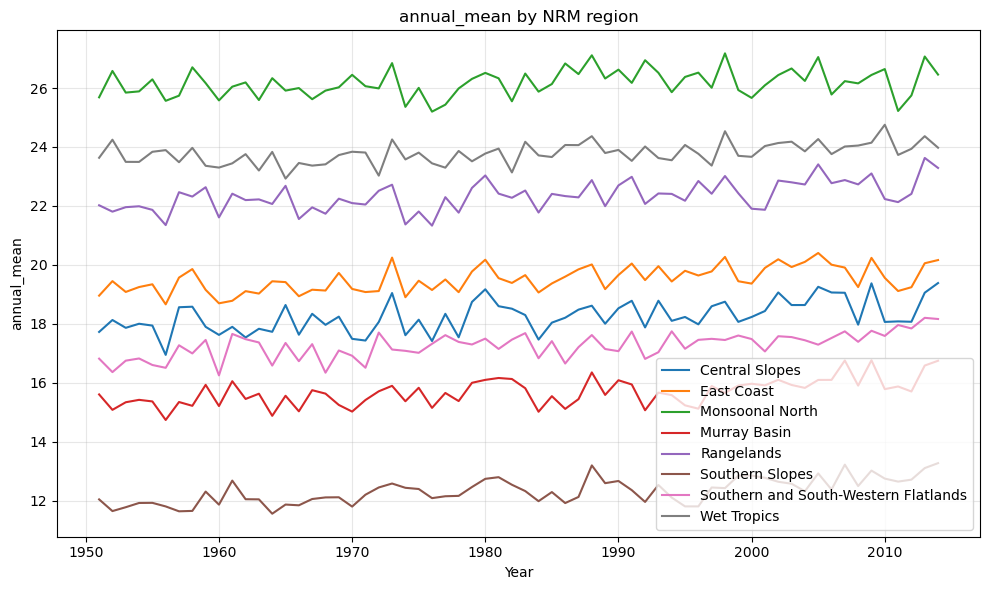

In [4]:
#(superseded)
yearly_csv = generate_annual_and_spatial_stats(
    variable="tas",
    data_dir="/scratch/dt6/xw9650/tmp/regridded_AGCD",
    nrm_shapefile="/scratch/dt6/xw9650/tmp/reference_data/NRM_clusters/NRM_clusters.shp",
    start_year=1951,
    end_year=2014,
    # overwrite=True,
)
plot_nrm_timeseries( yearly_csv)

Central Slopes trend (slope per year): 0.0213
East Coast trend (slope per year): 0.0158
Monsoonal North trend (slope per year): 0.0009
Murray Basin trend (slope per year): 0.0258
Rangelands trend (slope per year): 0.0170
Southern Slopes trend (slope per year): 0.0239
Southern and South-Western Flatlands trend (slope per year): 0.0102
Wet Tropics trend (slope per year): 0.0125


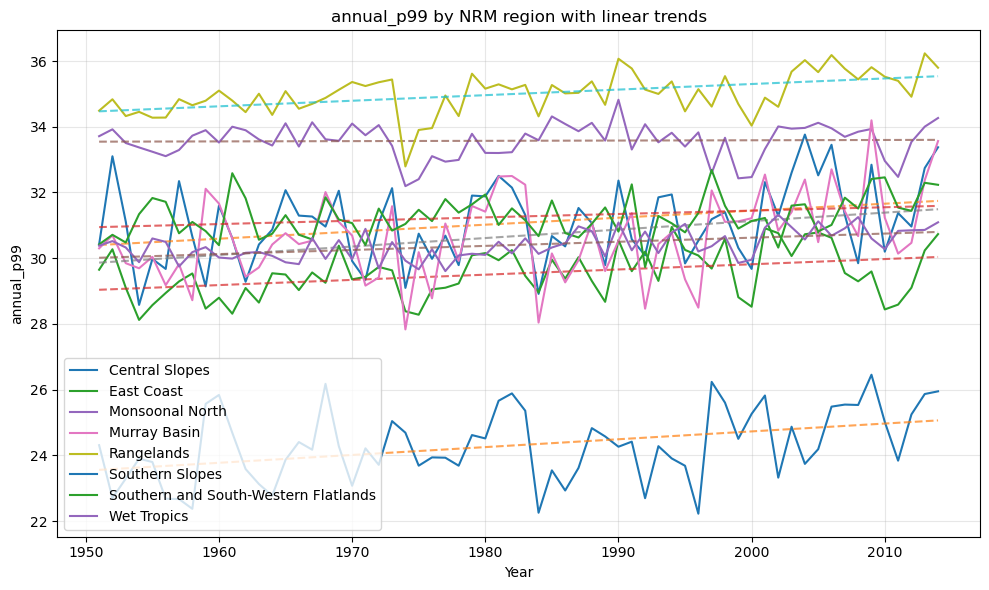

In [7]:
#(superseded) 3.1 run annual stats and plot 
import re
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import regionmask
import matplotlib.pyplot as plt

variable="tas"
data_dir="/scratch/dt6/xw9650/tmp/regridded_AGCD"
start_year=1951
end_year=2014
tag = _year_tag(start_year, end_year)

yearly_csv =  f"{data_dir}/annual_stats_{variable}_NRM_{tag}.csv"
plot_nrm_timeseries( yearly_csv)

In [5]:
#4. generate tas files by year (using tmin and tmax) 
import re
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import regionmask
import matplotlib.pyplot as plt

def _year_tag(start_year=None, end_year=None):
    s = str(start_year) if start_year is not None else "start"
    e = str(end_year) if end_year is not None else "end"
    return f"{s}-{e}"


def _select_files(data_dir, variable, statistic="mean", member="r005", start_year=None, end_year=None):

    pattern = f"agcd_v1_{variable}_{statistic}_{member}_daily_*.nc"
    files_all = sorted(Path(data_dir).glob(pattern))

    files = []
    for f in files_all:

        m = re.search(r"(\d{4})", f.name)
        if not m:
            continue

        y = int(m.group(1))

        if start_year and y < start_year:
            continue

        if end_year and y > end_year:
            continue

        files.append(f)

    return files

def generate_tas_files(
        data_dir,
        out_dir=None,
        statistic="mean",
        member="r005",
        start_year=None,
        end_year=None,
        overwrite=False,
):
    """
    Convert tmax + tmin → tas and save yearly NetCDF files
    """

    data_dir = Path(data_dir)
    out_dir = Path(out_dir) if out_dir else data_dir

    files_tmax = _select_files(data_dir, "tmax", statistic, member, start_year, end_year)
    files_tmin = _select_files(data_dir, "tmin", statistic, member, start_year, end_year)

    for fmax, fmin in zip(files_tmax, files_tmin):

        year_match = re.search(r"(\d{4})", fmax.name)
        year = year_match.group(1)

        out_file = out_dir / f"agcd_v1_tas_{statistic}_{member}_daily_{year}.nc"

  

        print(f"Processing TAS for year {year}")

        ds_max = xr.open_dataset(fmax)
        ds_min = xr.open_dataset(fmin)

        tas = (ds_max["tmax"] + ds_min["tmin"]) / 2
        tas.name = "tas"

        # keep attributes clean
        tas.attrs["long_name"] = "Near-surface air temperature"
        tas.attrs["units"] = ds_max["tmax"].attrs.get("units", "")

        ds_out = tas.to_dataset()

        ds_out.to_netcdf(out_file)

        ds_max.close()
        ds_min.close()

        print(f"[SAVED] {out_file}")

In [6]:
#4.1 execute
generate_tas_files(
    data_dir="/scratch/dt6/xw9650/tmp/regridded_AGCD",
    out_dir="/scratch/dt6/xw9650/tmp/regridded_AGCD",
    start_year=1951,
    end_year=2025,
)

Processing TAS for year 1951
[SAVED] /scratch/dt6/xw9650/tmp/regridded_AGCD/agcd_v1_tas_mean_r005_daily_1951.nc
Processing TAS for year 1952
[SAVED] /scratch/dt6/xw9650/tmp/regridded_AGCD/agcd_v1_tas_mean_r005_daily_1952.nc
Processing TAS for year 1953
[SAVED] /scratch/dt6/xw9650/tmp/regridded_AGCD/agcd_v1_tas_mean_r005_daily_1953.nc
Processing TAS for year 1954
[SAVED] /scratch/dt6/xw9650/tmp/regridded_AGCD/agcd_v1_tas_mean_r005_daily_1954.nc
Processing TAS for year 1955
[SAVED] /scratch/dt6/xw9650/tmp/regridded_AGCD/agcd_v1_tas_mean_r005_daily_1955.nc
Processing TAS for year 1956
[SAVED] /scratch/dt6/xw9650/tmp/regridded_AGCD/agcd_v1_tas_mean_r005_daily_1956.nc
Processing TAS for year 1957
[SAVED] /scratch/dt6/xw9650/tmp/regridded_AGCD/agcd_v1_tas_mean_r005_daily_1957.nc
Processing TAS for year 1958
[SAVED] /scratch/dt6/xw9650/tmp/regridded_AGCD/agcd_v1_tas_mean_r005_daily_1958.nc
Processing TAS for year 1959
[SAVED] /scratch/dt6/xw9650/tmp/regridded_AGCD/agcd_v1_tas_mean_r005_daily_

In [3]:
#5.0  
#calculate 99th percentile historical baseline, exceedance for AGCD
import xarray as xr
import dask
from filelock import FileLock
import glob 


def load_dataset(data_dir, variable, statistic="mean", member="r005"):
    path_mask = (
        f"{data_dir}/agcd_v1_{variable}_{statistic}_{member}_daily_*.nc"
    )
    print("data_dir =", data_dir)
    print("pattern =", path_mask)
    files = glob.glob(path_mask)

    # def sanitize(ds):
    #     return ds.drop_dims('crs')
    def sanitize(ds):
        if "crs" in ds.dims:
            ds = ds.drop_dims("crs")
        if "crs" in ds.variables:
            ds = ds.drop_vars("crs")
        return ds

    with dask.config.set(**{'array.slicing.split_large_chunks': False}):
        ds = xr.open_mfdataset(files, preprocess=sanitize, combine='by_coords')
    
    return ds.chunk(chunks={'time': -1, 'lat': 'auto', 'lon': 'auto'})


def determine_univariate(
    data, 
    out_prefix, 
    thresh=0.99, 
    ttype='q+',
    baseline_start="1951-01-01",
    baseline_end="2014-12-31",
    period_start="1951-01-01",
    period_end="2025-12-31"
):
    # Same logic...
    # ========================================================
    # SELECT BASELINE PERIOD
    # ========================================================
    
    data_sel=data.sel(
        time=slice(
            period_start,
            period_end
        )
    )
    
    baseline_data = data.sel(
        time=slice(
            baseline_start,
            baseline_end
        )
    )
    
    # ========================================================
    # COMPUTE THRESHOLD
    # ========================================================
    
    if 'q' in ttype:
        threshold = baseline_data.quantile(thresh, 'time', skipna=True)
    else:
        threshold = thresh
    
        
    univ_exceed = xr.where(data_sel > threshold, 1, 0) if '+' in ttype else xr.where(data_sel < threshold, 1, 0)

        
    suffix = f"{period_start[:4]}_{period_end[:4]}"
    
    out_file = f"{out_prefix}_univ_exceed_{suffix}.nc"
    threshold_out_file = f"{out_prefix}_threshold_{suffix}.nc"
    
    
    with FileLock(f"{out_file}.lock"):
        univ_exceed.to_netcdf(out_file)
    with FileLock(f"{threshold_out_file}.lock"):
        threshold.to_netcdf(threshold_out_file)

# def exceedance_univariate(data, threshold_file, out_file, ttype='q+'):
#     threshold = xr.open_dataset(threshold_file)
#     univ_exceed = xr.where(data > threshold, 1, 0) if '+' in ttype else xr.where(data < threshold, 1, 0)
    
#     with FileLock(f"{out_file}.lock"):
#         univ_exceed.to_netcdf(out_file)



In [2]:
#5.0.1 run the function

variable = 'tas'   
data_dir = '/scratch/dt6/xw9650/tmp/regridded_AGCD/'
out_dir = '/scratch/dt6/xw9650/tmp/regridded_AGCD/'
                
data = load_dataset(data_dir, variable, statistic="mean", member="r005")

prefix = f"{out_dir}{variable}"
                
determine_univariate(
    data[variable], 
    prefix, 
    thresh=0.99, 
    ttype='q+',
    baseline_start="1951-01-01",
    baseline_end="2014-12-31",
    period_start="1951-01-01",
    period_end="2025-12-31",
)


data_dir = /scratch/dt6/xw9650/tmp/regridded_AGCD/
pattern = /scratch/dt6/xw9650/tmp/regridded_AGCD//agcd_v1_tas_mean_r005_daily_*.nc


In [2]:
#5.0.2 run the function -for precip

variable = 'precip'   
data_dir = '/scratch/dt6/xw9650/tmp/regridded_AGCD/'
out_dir = '/scratch/dt6/xw9650/tmp/regridded_AGCD/'
                
data = load_dataset(data_dir, variable, statistic="total", member="r005")

prefix = f"{out_dir}{variable}"
                
determine_univariate(
    data[variable], 
    prefix, 
    thresh=0.99, 
    ttype='q+',
    baseline_start="1951-01-01",
    baseline_end="2014-12-31",
    period_start="1951-01-01",
    period_end="2025-12-31",
)


data_dir = /scratch/dt6/xw9650/tmp/regridded_AGCD/
pattern = /scratch/dt6/xw9650/tmp/regridded_AGCD//agcd_v1_precip_total_r005_daily_*.nc
